### XGBoost Model made with PyTorch
Relevant Statistics: 
| Category          | Accuracy | Precision | Recall | F1     | AUC    |
|-------------------|----------|-----------|--------|--------|--------|
| any               | 0.8322   | 0.8154    | 0.7629 | 0.7883 | 0.8964 |
| epidural          | 0.9851   | 0.0000    | 0.0000 | 0.0000 | 0.6795 |
| intraparenchymal  | 0.7699   | 0.5488    | 0.4075 | 0.4677 | 0.7988 |
| intraventricular  | 0.8118   | 0.3526    | 0.0980 | 0.1534 | 0.7614 |
| subarachnoid      | 0.7997   | 0.4086    | 0.1242 | 0.1905 | 0.7783 |
| subdural          | 0.8031   | 0.3719    | 0.1267 | 0.1890 | 0.7664 |

AUC = 0.896 Overall

In [6]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

import xgboost as xgb

In [2]:
# Load the datasets into pandas DataFrames
df_hemo = pd.read_csv('../Rsna_ICH_Hemm.csv')
df_control = pd.read_csv('../Rsna_ICH_Control.csv')

# Combine the datasets
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Define the target columns in the proper order
target_columns = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

In [3]:
# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_columns].values.astype(np.float32)

# Split the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
xgb_models = []
xgb_params = []
for i, col in enumerate(target_columns):
    print(f'Training XGBoost for {col}...')
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': 6,
        'learning_rate': 0.1,
        'n_estimators': 100,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_scaled, y_train[:, i])
    xgb_models.append(model)
    xgb_params.append(params)


Training XGBoost for any...
Training XGBoost for epidural...
Training XGBoost for intraparenchymal...
Training XGBoost for intraventricular...
Training XGBoost for subarachnoid...
Training XGBoost for subdural...


In [7]:
y_pred_xgb = np.zeros_like(y_test)
y_pred_proba_xgb = np.zeros_like(y_test, dtype=float)

for i, model in enumerate(xgb_models):
    y_pred_xgb[:, i] = model.predict(X_test_scaled)
    y_pred_proba_xgb[:, i] = model.predict_proba(X_test_scaled)[:, 1]

xgb_metrics = []
for i, col in enumerate(target_columns):
    acc = accuracy_score(y_test[:, i], y_pred_xgb[:, i])
    prec = precision_score(y_test[:, i], y_pred_xgb[:, i], zero_division=0)
    rec = recall_score(y_test[:, i], y_pred_xgb[:, i], zero_division=0)
    f1 = f1_score(y_test[:, i], y_pred_xgb[:, i], zero_division=0)
    if len(np.unique(y_test[:, i])) > 1:
        fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_proba_xgb[:, i])
        auc_score = auc(fpr, tpr)
    else:
        auc_score = 0.0
    xgb_metrics.append({
        'Category': col,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'AUC': auc_score
    })

xgb_metrics_df = pd.DataFrame(xgb_metrics)
print(xgb_metrics_df.round(4))

           Category  Accuracy  Precision  Recall      F1     AUC
0               any    0.8322     0.8154  0.7629  0.7883  0.8964
1          epidural    0.9851     0.0000  0.0000  0.0000  0.6795
2  intraparenchymal    0.7699     0.5488  0.4075  0.4677  0.7988
3  intraventricular    0.8118     0.3526  0.0980  0.1534  0.7614
4      subarachnoid    0.7997     0.4086  0.1242  0.1905  0.7783
5          subdural    0.8031     0.3719  0.1267  0.1890  0.7664


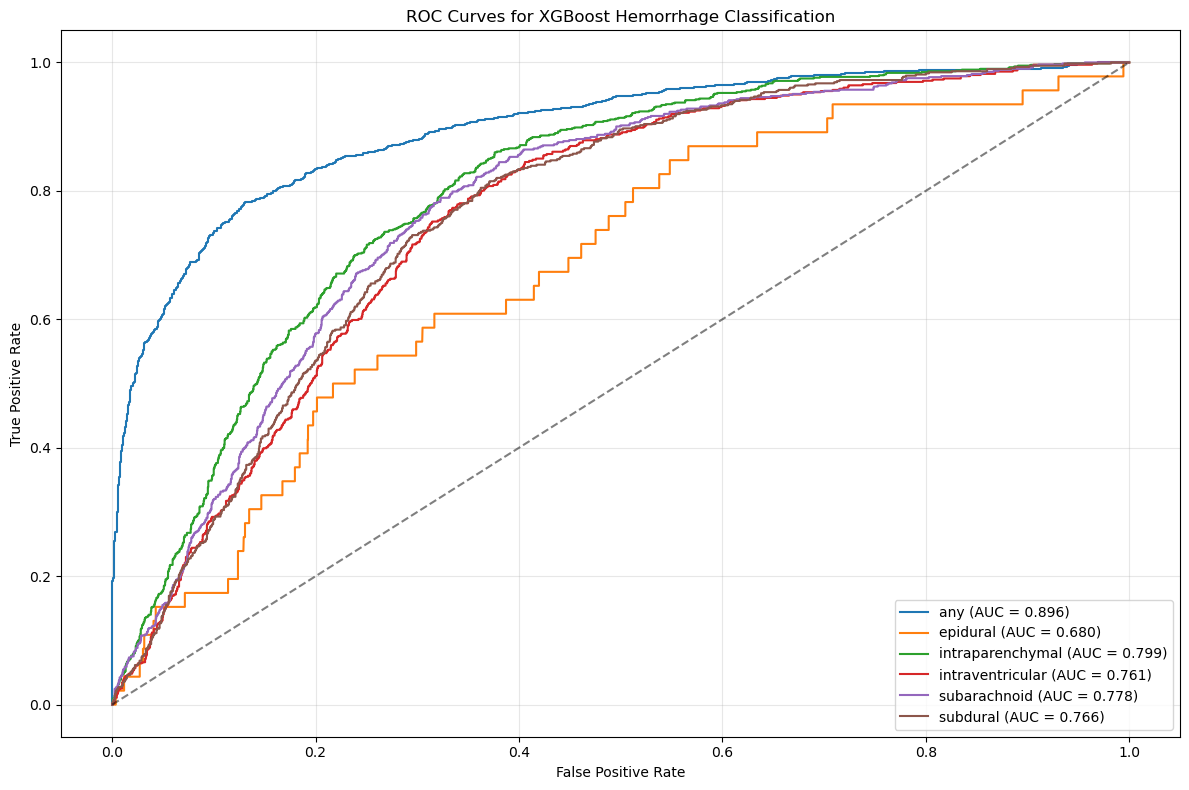

In [8]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(target_columns):
    if len(np.unique(y_test[:, i])) > 1:
        y_score = y_pred_proba_xgb[:, i]
        fpr, tpr, _ = roc_curve(y_test[:, i], y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{col} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for XGBoost Hemorrhage Classification')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
